# **Workflow Optimization Model**

This model optimizes startup workflow tasks using a greedy-based scheduling algorithm.

It prioritizes tasks based on:
- Task priority
- Deadline urgency
- Resource availability

The goal is to improve productivity and reduce task delays.


## Problem Statement

Startups handle multiple tasks across different departments such as
Marketing, Finance, Tech, and HR.

Efficient task scheduling is necessary to:
- Complete urgent tasks on time
- Use available resources effectively
- Improve overall workflow efficiency

This model assigns an optimization score to each task
and schedules tasks based on that score.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Load Dataset

We use a custom-generated dataset containing 3000 workflow tasks.


In [2]:
df = pd.read_csv("workflow_dataset_3000.csv")

df.head()


,Task_ID,Department,Task_Type,Priority,Deadline_Days,Estimated_Hours,Resource_Available
0,1,Tech,Payment,5,30,3,0
1,2,HR,Support,2,8,16,1
2,3,Marketing,Hiring,4,25,15,0
3,4,Tech,Hiring,3,10,11,1
4,5,Tech,Payment,3,2,18,0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Task_ID             3000 non-null   int64 
 1   Department          3000 non-null   object
 2   Task_Type           3000 non-null   object
 3   Priority            3000 non-null   int64 
 4   Deadline_Days       3000 non-null   int64 
 5   Estimated_Hours     3000 non-null   int64 
 6   Resource_Available  3000 non-null   int64 
dtypes: int64(5), object(2)
memory usage: 164.2+ KB


## Optimization Algorithm

We use a Greedy Scheduling approach.

Optimization Score Formula:

Score =
(Priority × 3) +
(10 / Deadline_Days) +
(Resource_Available × 5)

Explanation:
- Higher priority increases score.
- Shorter deadline increases urgency score.
- If resources are available, score increases.

Tasks with higher scores are executed first.


In [4]:
df["Optimization_Score"] = (
    df["Priority"] * 3 +
    (10 / df["Deadline_Days"]) +
    df["Resource_Available"] * 5
)

df.head()


,Task_ID,Department,Task_Type,Priority,Deadline_Days,Estimated_Hours,Resource_Available,Optimization_Score
0,1,Tech,Payment,5,30,3,0,15.333333
1,2,HR,Support,2,8,16,1,12.250000
2,3,Marketing,Hiring,4,25,15,0,12.400000
3,4,Tech,Hiring,3,10,11,1,15.000000
4,5,Tech,Payment,3,2,18,0,14.000000


## Before Optimization

Tasks are in random order.


In [5]:
print("Before Optimization (First 10 Tasks)")
print(df.head(10))


Before Optimization (First 10 Tasks)
   Task_ID Department Task_Type  Priority  Deadline_Days  Estimated_Hours  \
0        1       Tech   Payment         5             30                3   
1        2         HR   Support         2              8               16   
2        3  Marketing    Hiring         4             25               15   
3        4       Tech    Hiring         3             10               11   
4        5       Tech   Payment         3              2               18   
5        6         HR  Campaign         2              9               15   
6        7  Marketing   Support         3             24                5   
7        8  Marketing    Hiring         3             23               16   
8        9       Tech   Payment         1              3               16   
9       10    Finance    Hiring         4             18               17   

   Resource_Available  Optimization_Score  
0                   0           15.333333  
1                   1      

## Apply Optimization

We sort tasks in descending order of Optimization Score.


In [6]:
df_optimized = df.sort_values(by="Optimization_Score", ascending=False)

print("After Optimization (Top 10 Tasks)")
print(df_optimized.head(10))


After Optimization (Top 10 Tasks)
      Task_ID Department    Task_Type  Priority  Deadline_Days  \
1237     1238         HR  Development         5              1   
538       539  Marketing  Development         5              1   
2844     2845    Finance  Development         5              1   
1001     1002       Tech      Support         5              1   
1623     1624         HR  Development         5              1   
792       793  Marketing      Support         5              1   
859       860       Tech       Hiring         5              1   
156       157       Tech      Payment         5              1   
2445     2446  Marketing      Payment         5              1   
2472     2473       Tech      Payment         5              1   

      Estimated_Hours  Resource_Available  Optimization_Score  
1237               19                   1                30.0  
538                16                   1                30.0  
2844                2                   1      

## Visualization

We visualize:
1. Priority distribution before and after optimization.
2. Top optimized tasks based on score.


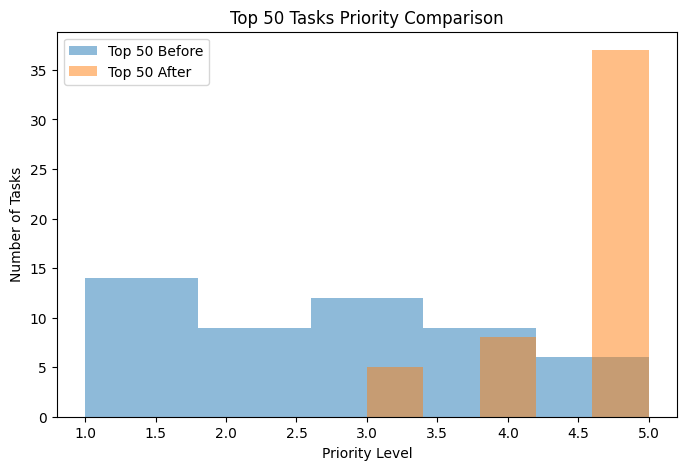

In [9]:
# Top 50 before optimization
top_before = df.head(50)

# Top 50 after optimization
top_after = df_optimized.head(50)

plt.figure(figsize=(8,5))

plt.hist(top_before["Priority"], bins=5, alpha=0.5, label="Top 50 Before")
plt.hist(top_after["Priority"], bins=5, alpha=0.5, label="Top 50 After")

plt.title("Top 50 Tasks Priority Comparison")
plt.xlabel("Priority Level")
plt.ylabel("Number of Tasks")
plt.legend()
plt.show()



## Optimization Score Comparison

This graph compares the average optimization score of the top 50 tasks
before and after applying the workflow optimization algorithm.

The red bar (Before Optimization) represents the average score of tasks
in their original random order.

The green bar (After Optimization) represents the average score of tasks
after sorting based on the calculated optimization score.

A higher average score after optimization indicates that:
- High-priority tasks are scheduled earlier.
- Urgent deadlines are considered properly.
- Available resources are utilized effectively.

This confirms that the workflow optimization model
successfully improves task scheduling efficiency.


Average Score (Top 50 Before): 11.972095078786896
Average Score (Top 50 After): 26.72


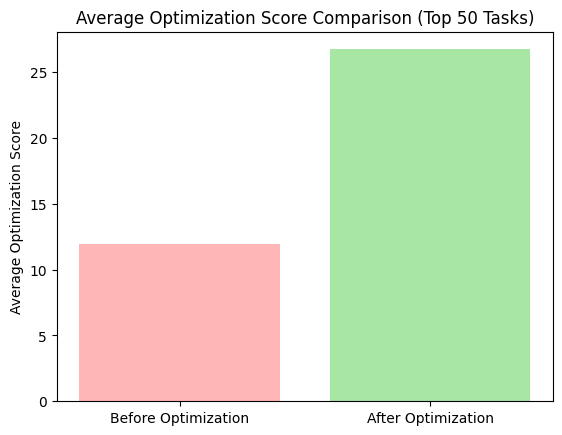

In [13]:
# Top 50 tasks before optimization
top_before = df.head(50)

# Top 50 tasks after optimization
top_after = df_optimized.head(50)

# Calculate average scores
avg_score_before = top_before["Optimization_Score"].mean()
avg_score_after = top_after["Optimization_Score"].mean()

print("Average Score (Top 50 Before):", avg_score_before)
print("Average Score (Top 50 After):", avg_score_after)

# Plot comparison with different colors
plt.figure()

plt.bar(
    ["Before Optimization", "After Optimization"],
    [avg_score_before, avg_score_after],
    color=["#FFB6B6", "#A8E6A3"]   # Different colors
)

plt.title("Average Optimization Score Comparison (Top 50 Tasks)")
plt.ylabel("Average Optimization Score")
plt.show()


## Save Optimized Workflow

The optimized dataset is saved for backend integration.


In [8]:
df_optimized.to_csv("workflow_optimized_3000.csv", index=False)

print("Optimized workflow saved successfully ✅")


Optimized workflow saved successfully ✅


## Model Evaluation

This is not a machine learning prediction model.
It is a rule-based optimization system.

Evaluation is based on:
- Proper prioritization of urgent tasks
- Efficient resource utilization
- Improved scheduling order

The model successfully ranks tasks based on importance and urgency.


## Model Summary

Model Name: Workflow Optimization Model
Type: Greedy-Based Scheduling Algorithm
Input: Task Priority, Deadline, Resource Availability
Output: Optimized Task Execution Order

The model improves workflow efficiency by ranking tasks
according to their calculated optimization score.
